In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score , mean_squared_log_error

In [3]:
df = pd.read_csv('https://drive.google.com/uc?id=1UOUron79AUpb8HR7OF7cGATmJeAygrH-')

In [4]:
df['BrandName'] = df['CarName'].str.split(" ").str[0]

In [5]:
df['BrandName'].unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'maxda', 'mazda', 'buick', 'mercury',
       'mitsubishi', 'Nissan', 'nissan', 'peugeot', 'plymouth', 'porsche',
       'porcshce', 'renault', 'saab', 'subaru', 'toyota', 'toyouta',
       'vokswagen', 'volkswagen', 'vw', 'volvo'], dtype=object)

In [6]:
df['BrandName'] = df['BrandName'].replace({'maxda': 'mazda','Nissan' : 'nissan','porcshce' : 'porsche','toyouta' : 'toyota','vokswagen' : 'volkswagen','vw' : 'volkswagen'})

In [7]:
df['BrandName'].unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'mazda', 'buick', 'mercury', 'mitsubishi',
       'nissan', 'peugeot', 'plymouth', 'porsche', 'renault', 'saab',
       'subaru', 'toyota', 'volkswagen', 'volvo'], dtype=object)

In [8]:
df.drop(columns='car_ID', inplace=True)

In [9]:
df.drop(columns='CarName', inplace=True)

In [10]:
df['doornumber'] = df['doornumber'].replace({'two': 2, 'four': 4})

C:\Users\harsh\AppData\Local\Temp\ipykernel_21552\2076136068.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['doornumber'] = df['doornumber'].replace({'two': 2, 'four': 4})


In [11]:
df['doornumber'].unique()

array([2, 4], dtype=int64)

In [12]:
df.sample(5)

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,BrandName
182,2,diesel,std,2,sedan,fwd,front,97.3,171.7,65.5,...,idi,3.01,3.40,23.0,52,4800,37,46,7775.0,volkswagen
31,2,gas,std,2,hatchback,fwd,front,86.6,144.6,63.9,...,1bbl,2.91,3.41,9.2,76,6000,31,38,6855.0,honda
161,0,gas,std,4,hatchback,fwd,front,95.7,166.3,64.4,...,2bbl,3.19,3.03,9.0,70,4800,28,34,8358.0,toyota
166,1,gas,std,2,hatchback,rwd,front,94.5,168.7,64.0,...,mpfi,3.24,3.08,9.4,112,6600,26,29,9538.0,toyota
185,2,gas,std,4,sedan,fwd,front,97.3,171.7,65.5,...,mpfi,3.19,3.40,9.0,85,5250,27,34,8195.0,volkswagen


In [13]:
df_dummy = pd.get_dummies(df)

In [14]:
object_columns = df.select_dtypes(include=['object']).columns.tolist()
print("Object columns:", object_columns)

Object columns: ['fueltype', 'aspiration', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem', 'BrandName']


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df['enginesize'],df['price'],test_size=0.33,random_state=42)

In [16]:
def errors_product():
  prod = (X_train - X_train.mean()) * (y_train - y_train.mean())
  return prod

def squared_errors_product():
  prod = (X_train - X_train.mean()) ** 2
  return prod

slope = errors_product().sum()/squared_errors_product().sum()
intercept = y_train.mean() - (slope * X_train.mean())

print(f"Slope: {slope}")
print(f"Intercept: {intercept}")

Slope: 165.32203370071696
Intercept: -7590.257181325589


In [17]:
def predict(x):
  return (slope * x) + intercept

In [18]:
df['enginesize'].apply(lambda x: predict(x))

0      13901.607200
1      13901.607200
2      17538.691941
3      10429.844492
4      14893.539402
           ...     
200    15720.149570
201    15720.149570
202    21010.454649
203    16381.437705
204    15720.149570
Name: enginesize, Length: 205, dtype: float64

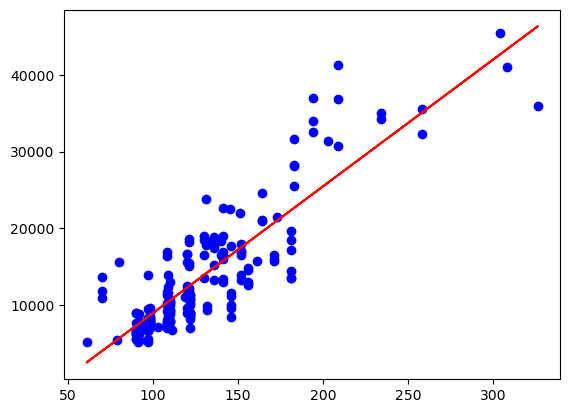

In [19]:
plt.scatter(df_dummy['enginesize'], df_dummy['price'], color='blue')
plt.plot(df_dummy['enginesize'], slope * df_dummy['enginesize'] + intercept, color='red')

In [20]:
def r_squared(y_true, y_pred):
  ss_total = ((y_true - y_true.mean()) ** 2).sum()
  ss_residual = ((y_true - y_pred) ** 2).sum()
  r2 = 1 - (ss_residual / ss_total)
  return r2

print("R-squared: (train)", r_squared(y_train, predict(X_train)))
print("R-squared (sklearn):", r2_score(y_train, predict(X_train)))
print("R-squared: (test)" , r_squared(y_test, predict(X_test)))
print("R-squared (sklearn):", r2_score(y_test, predict(X_test)))


R-squared: (train) 0.7650159366830336
R-squared (sklearn): 0.7650159366830336
R-squared: (test) 0.7606548315153334
R-squared (sklearn): 0.7606548315153334


In [21]:
np.corrcoef(X_train , y_train)[0,1]**2

0.7650159366830326

In [22]:
mean_squared_error(y_test, predict(X_test))

15661604.548448615

In [23]:
root_mean_squared_error = np.sqrt(mean_squared_error(y_test, predict(X_test)))
root_mean_squared_error

3957.4745164623127

In [24]:
mean_absolute_error = np.mean(np.abs(y_test - predict(X_test)))
mean_absolute_error

2773.990816101962

In [25]:
mean_squared_log_error = np.mean((np.log1p(y_test) - np.log1p(predict(X_test))) ** 2)
mean_squared_log_error


0.09333552536979683

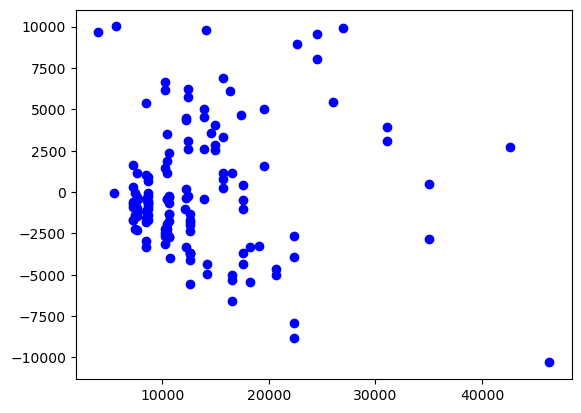

In [34]:
# Homoscedasticity check
plt.scatter(predict(X_train), y_train - predict(X_train), color='blue', label='Train Residuals')


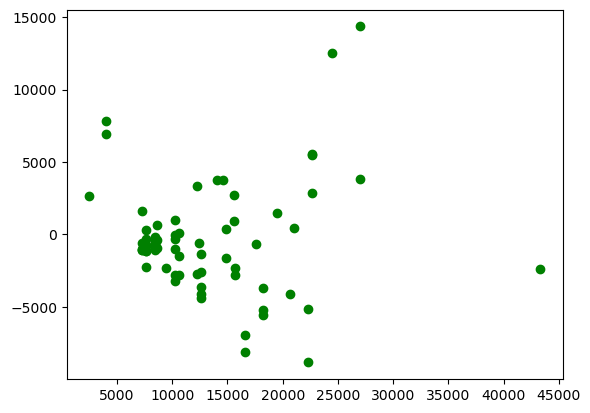

In [37]:
plt.scatter(predict(X_test), y_test - predict(X_test), color='green', label='Test Residuals')

In [38]:
# Multiple Linear Regression Model

In [49]:
# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df_dummy.drop(columns='price'), df_dummy['price'], test_size=0.33, random_state=42)

In [47]:
df_dummy.shape

(205, 74)